# 02a — Port Weight Optimisation

Calibrates the three port-selection parameters using IMF data.

| Parameter | Meaning | Calibrated against |
|-----------|---------|-------------------|
| `alpha` | Exponent on port size score | Vessel-count-based port share (AIS data) |
| `beta` | Exponent on vessel-type score | Per-port vessel-type fractions (AIS data) |
| `lambda` | Distance penalty scale | Vessel-count-based port share (AIS data) |

**Why these targets?**
- *JS_size_vs_vc*: Compares the model's simulated marginal port distribution (`import_size^alpha × exp(−λ × avg_excess)`) to the empirical **vessel-count-based** port share (`Σ_t vessel_count_t[i]` normalised). These are genuinely independent data sources: `import_size` comes from BACI trade shares; vessel counts come from AIS/port statistics.
- *JS_type*: Compares per-port vessel-type fractions under `type_score^beta` to empirical type fractions from vessel counts. Alpha and lambda cancel in the per-port ratio, so beta is calibrated independently.

**Objective**: `log(JS_size_vs_vc) + log(JS_type)` — geometric mean criterion, separable in (alpha, λ) vs beta.

**Algorithm**: scipy `minimize_scalar` (Brent) for beta, `L-BFGS-B` (multi-start) for (alpha, λ).

**No ships are generated.** Port distributions are computed analytically.

**Prerequisites:** `simulation_config.ipynb`, `00_precompute_routes.ipynb`

**Output:** `PORT_WEIGHT_ALPHA`, `PORT_WEIGHT_BETA`, `DISTANCE_PENALTY_SCALE` to copy into `simulation_config.json`, then re-run `01_ship_generation.ipynb`.

In [37]:
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, str(Path.cwd()))

from simulation_engine.config_loader import load_config, resolve_paths
from simulation_engine.routing import build_port_node_map, build_country_port_map
from simulation_engine.port_weight_optimizer import (
    build_raw_port_data,
    precompute_avg_excess_ratios,
    compute_js_type,
    compute_js_size_vs_vc,
    compute_objective_3d,
    optimize_all,
    beta_sweep,
    js_divergence,
)

In [38]:
# ============================================================
# Load configuration
# ============================================================
cfg = load_config()
cfg = resolve_paths(cfg)
print("Config loaded.")
print(f"  Network  : {cfg['NETWORK_FILE']}")
print(f"  IMF ports: {cfg['IMF_PORT_DATA_FILE']}")
print(f"  Routes   : {cfg['OUTPUT_DIR']}/port_pair_routes.pkl")

Config loaded.
  Network  : /Users/finn-frederikhopmann/Documents/Minerva/Academics/Year 4/Semester 7/CP193/Data Fun/simulation_pipeline/part_3_network_extraction/network_outputs/network_calibrated.gpickle
  IMF ports: /Users/finn-frederikhopmann/Documents/Minerva/Academics/Year 4/Semester 7/CP193/Data Fun/data/port_data_imf.csv
  Routes   : /Users/finn-frederikhopmann/Documents/Minerva/Academics/Year 4/Semester 7/CP193/Data Fun/simulation_pipeline/part_4_new_simulation/simulation_output_data/scenario_eu_trade_deals_and_tariffs/port_pair_routes.pkl


In [39]:
# ============================================================
# Load network and pre-computed routes
# ============================================================
print("Loading network...")
with open(cfg['NETWORK_FILE'], 'rb') as f:
    G = pickle.load(f)
print(f"  {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

port_name_to_node = build_port_node_map(G)
country_to_ports  = build_country_port_map(G)
print(f"  {len(port_name_to_node):,} ports, {len(country_to_ports):,} countries")

# ── Locate route files ────────────────────────────────────────────────────────
# port_pair_routes.pkl and country_pair_optimal.pkl are network-level (not
# scenario-specific), but may have been saved into a scenario subdirectory
# if OUTPUT_DIR was set to a scenario path when 00_precompute_routes was run.
output_dir = Path(cfg['OUTPUT_DIR'])

def _find_routes_dir(base: Path) -> Path:
    """Return the directory containing port_pair_routes.pkl."""
    if (base / 'port_pair_routes.pkl').exists():
        return base
    # Search one level of subdirectories (scenario folders)
    candidates = sorted(
        [d for d in base.iterdir() if d.is_dir() and (d / 'port_pair_routes.pkl').exists()],
        key=lambda d: d.stat().st_mtime, reverse=True,
    )
    if candidates:
        return candidates[0]
    raise FileNotFoundError(
        f"port_pair_routes.pkl not found in {base} or any subdirectory.\n"
        "Run 00_precompute_routes.ipynb first."
    )

routes_dir = _find_routes_dir(output_dir)
print(f"\nRoute files found in: {routes_dir}")

print("Loading port-pair routes...")
with open(routes_dir / 'port_pair_routes.pkl', 'rb') as f:
    port_pair_routes = pickle.load(f)
print(f"  {len(port_pair_routes):,} directed port-pair routes")

print("Loading country-pair optimal routes...")
with open(routes_dir / 'country_pair_optimal.pkl', 'rb') as f:
    country_pair_optimal = pickle.load(f)
print(f"  {len(country_pair_optimal):,} country pairs")

print("Loading IMF port data...")
imf_port_df = pd.read_csv(cfg['IMF_PORT_DATA_FILE'])
baci_codes  = pd.read_csv(cfg['BACI_CODES_FILE'])
iso3_to_baci = dict(zip(baci_codes['country_iso3'], baci_codes['country_name']))
imf_port_df['baci_name'] = imf_port_df['ISO3'].map(iso3_to_baci)
print(f"  {len(imf_port_df):,} ports loaded")

Loading network...
  8,726 nodes, 14,634 edges
  588 ports, 168 countries

Route files found in: /Users/finn-frederikhopmann/Documents/Minerva/Academics/Year 4/Semester 7/CP193/Data Fun/simulation_pipeline/part_4_new_simulation/simulation_output_data/scenario_eu_trade_deals_and_tariffs
Loading port-pair routes...
  345,156 directed port-pair routes
Loading country-pair optimal routes...
  28,056 country pairs
Loading IMF port data...
  2,033 ports loaded


In [40]:
# ============================================================
# Build raw port data + precompute average excess ratios
# (run once — independent of alpha / beta / lam)
# ============================================================
print("Building raw port data from IMF...")
raw_port_data = build_raw_port_data(country_to_ports, imf_port_df)
print(f"  Raw port data built for {len(raw_port_data):,} countries")

print("Precomputing average excess ratios (this may take ~1 min)...")
avg_excess_ratios = precompute_avg_excess_ratios(
    raw_port_data, port_pair_routes, country_pair_optimal, country_to_ports
)
print(f"  Excess ratios computed for {len(avg_excess_ratios):,} countries")

# Sanity check at reference parameters
print(f"\nSanity check:")
for a, b, l in [(1.0, 0.0, 0.0), (1.0, 1.0, 1.0), (1.0, 1.0, 3.0)]:
    js_s = compute_js_size_vs_vc(raw_port_data, avg_excess_ratios, a, l)
    js_t = compute_js_type(raw_port_data, b)
    print(f"  (α={a}, β={b}, λ={l})  JS_size={js_s:.4f}  JS_type={js_t:.4f}")

Building raw port data from IMF...
  Raw port data built for 168 countries
Precomputing average excess ratios (this may take ~1 min)...
  Excess ratios computed for 168 countries

Sanity check:
  (α=1.0, β=0.0, λ=0.0)  JS_size=0.0361  JS_type=0.0984
  (α=1.0, β=1.0, λ=1.0)  JS_size=0.0370  JS_type=0.0583
  (α=1.0, β=1.0, λ=3.0)  JS_size=0.0403  JS_type=0.0583


In [41]:
# ============================================================
# Optimisation bounds
# ============================================================
ALPHA_BOUNDS = (0.0, 3.0)   # size exponent
BETA_BOUNDS  = (0.0, 6.0)   # type exponent (>4 effectively saturates)
LAM_BOUNDS   = (0.0, 6.0)   # distance penalty scale

# Sweep resolution for landscape plots
N_SWEEP = 50

print(f"alpha bounds : {ALPHA_BOUNDS}")
print(f"beta  bounds : {BETA_BOUNDS}")
print(f"lam   bounds : {LAM_BOUNDS}")
print(f"Algorithm    : Brent (beta) + L-BFGS-B multi-start (alpha, lam)")

alpha bounds : (0.0, 3.0)
beta  bounds : (0.0, 6.0)
lam   bounds : (0.0, 6.0)
Algorithm    : Brent (beta) + L-BFGS-B multi-start (alpha, lam)


In [42]:
# ============================================================
# Run joint 3-D optimisation
# ============================================================
import math

print("Running optimisation...")
opt = optimize_all(
    raw_port_data,
    avg_excess_ratios,
    alpha_bounds=ALPHA_BOUNDS,
    beta_bounds=BETA_BOUNDS,
    lam_bounds=LAM_BOUNDS,
)

print(f"\n{'='*55}")
print(f"OPTIMAL PARAMETERS")
print(f"{'='*55}")
print(f"  PORT_WEIGHT_ALPHA     (alpha)  = {opt['best_alpha']:.4f}")
print(f"  PORT_WEIGHT_BETA      (beta)   = {opt['best_beta']:.4f}")
print(f"  DISTANCE_PENALTY_SCALE (lam)  = {opt['best_lam']:.4f}")
print(f"{'='*55}")
print(f"  JS_size_vs_vc at optimum = {opt['best_js_size']:.5f}")
print(f"  JS_type       at optimum = {opt['best_js_type']:.5f}")
print(f"  Combined objective       = {opt['best_objective']:.4f}")
print(f"  Function evals: beta={opt['n_evals_beta']}, size={opt['n_evals_size']}")

# ── 1-D landscape sweeps ─────────────────────────────────────────────────────
print("\nSweeping 1-D landscapes for plots...")
beta_vals  = np.linspace(*BETA_BOUNDS,  N_SWEEP)
alpha_vals = np.linspace(*ALPHA_BOUNDS, N_SWEEP)
lam_vals   = np.linspace(*LAM_BOUNDS,   N_SWEEP)

sweep_js_type  = beta_sweep(raw_port_data, beta_vals, show_progress=False)
sweep_js_alpha = np.array([
    compute_js_size_vs_vc(raw_port_data, avg_excess_ratios, a, opt['best_lam'])
    for a in alpha_vals
])
sweep_js_lam = np.array([
    compute_js_size_vs_vc(raw_port_data, avg_excess_ratios, opt['best_alpha'], l)
    for l in lam_vals
])

# ── 2-D pairwise heatmaps (combined objective = log JS_size + log JS_type) ───
# alpha × lambda  (beta fixed at optimum) — requires full 2-D eval
print("Computing 2-D heatmap (alpha × lambda)...")
grid_js_size = np.zeros((N_SWEEP, N_SWEEP))
for i, a in enumerate(alpha_vals):
    for j, l in enumerate(lam_vals):
        grid_js_size[i, j] = compute_js_size_vs_vc(
            raw_port_data, avg_excess_ratios, a, l
        )
_log_js_type_opt = math.log(max(opt['best_js_type'], 1e-10))
grid_obj_alpha_lam = np.log(np.maximum(grid_js_size, 1e-10)) + _log_js_type_opt

# alpha × beta  (lambda fixed at optimum) — free via separability
print("Computing 2-D heatmap (alpha × beta)...")
log_js_size_alpha = np.log(np.maximum(sweep_js_alpha, 1e-10))  # shape (N_SWEEP,)
log_js_type_beta  = np.log(np.maximum(sweep_js_type,  1e-10))  # shape (N_SWEEP,)
grid_obj_alpha_beta = log_js_size_alpha[:, None] + log_js_type_beta[None, :]  # (N_alpha, N_beta)

# lambda × beta  (alpha fixed at optimum) — free via separability
print("Computing 2-D heatmap (lambda × beta)...")
log_js_size_lam = np.log(np.maximum(sweep_js_lam, 1e-10))  # shape (N_SWEEP,)
grid_obj_lam_beta = log_js_size_lam[:, None] + log_js_type_beta[None, :]  # (N_lam, N_beta)

print("Done.")

Running optimisation...

OPTIMAL PARAMETERS
  PORT_WEIGHT_ALPHA     (alpha)  = 0.5349
  PORT_WEIGHT_BETA      (beta)   = 0.8908
  DISTANCE_PENALTY_SCALE (lam)  = 0.0942
  JS_size_vs_vc at optimum = 0.02522
  JS_type       at optimum = 0.05805
  Combined objective       = -6.5264
  Function evals: beta=11, size=36

Sweeping 1-D landscapes for plots...
Computing 2-D heatmap (alpha × lambda)...
Computing 2-D heatmap (alpha × beta)...
Computing 2-D heatmap (lambda × beta)...
Done.


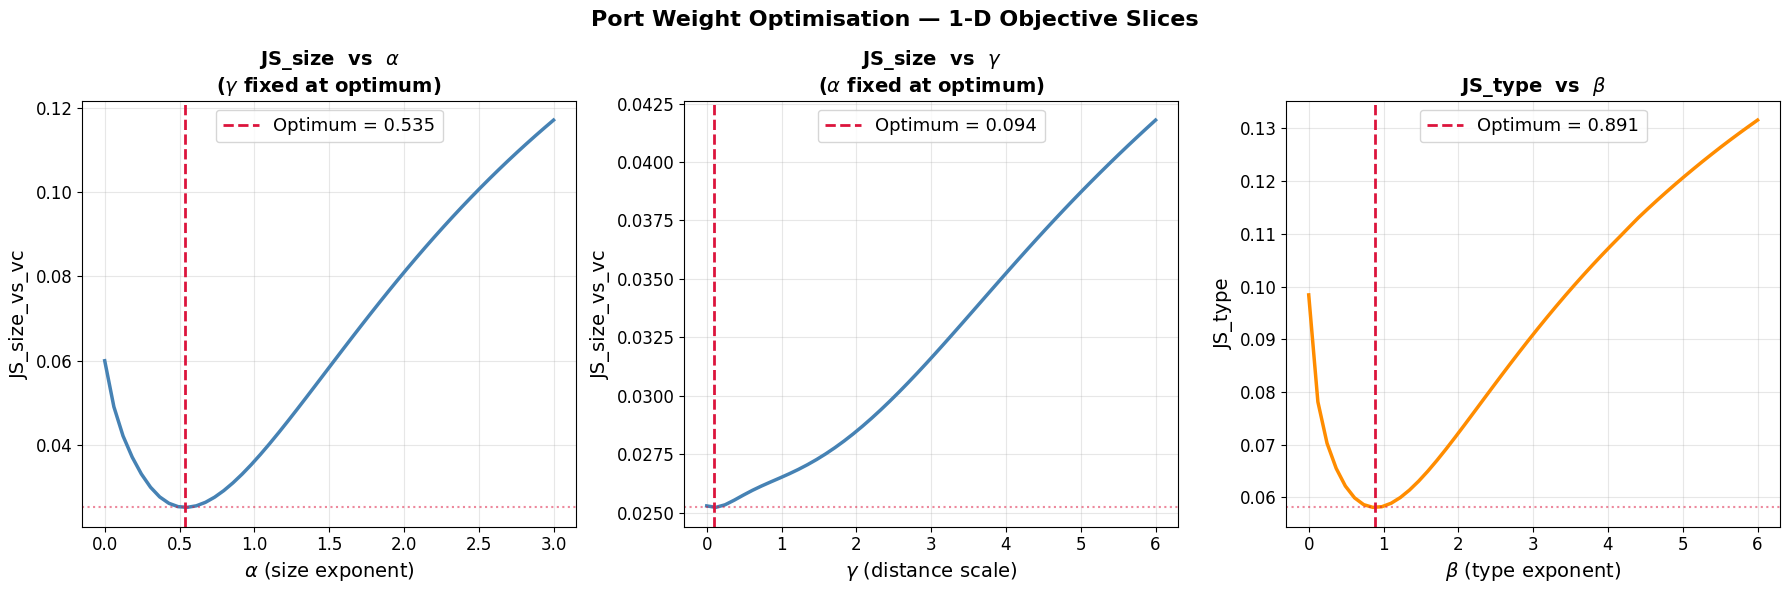

Saved to /Users/finn-frederikhopmann/Documents/Minerva/Academics/Year 4/Semester 7/CP193/Data Fun/simulation_pipeline/part_4_new_simulation/simulation_output_data/scenario_eu_trade_deals_and_tariffs/port_weight_1d_slices.png


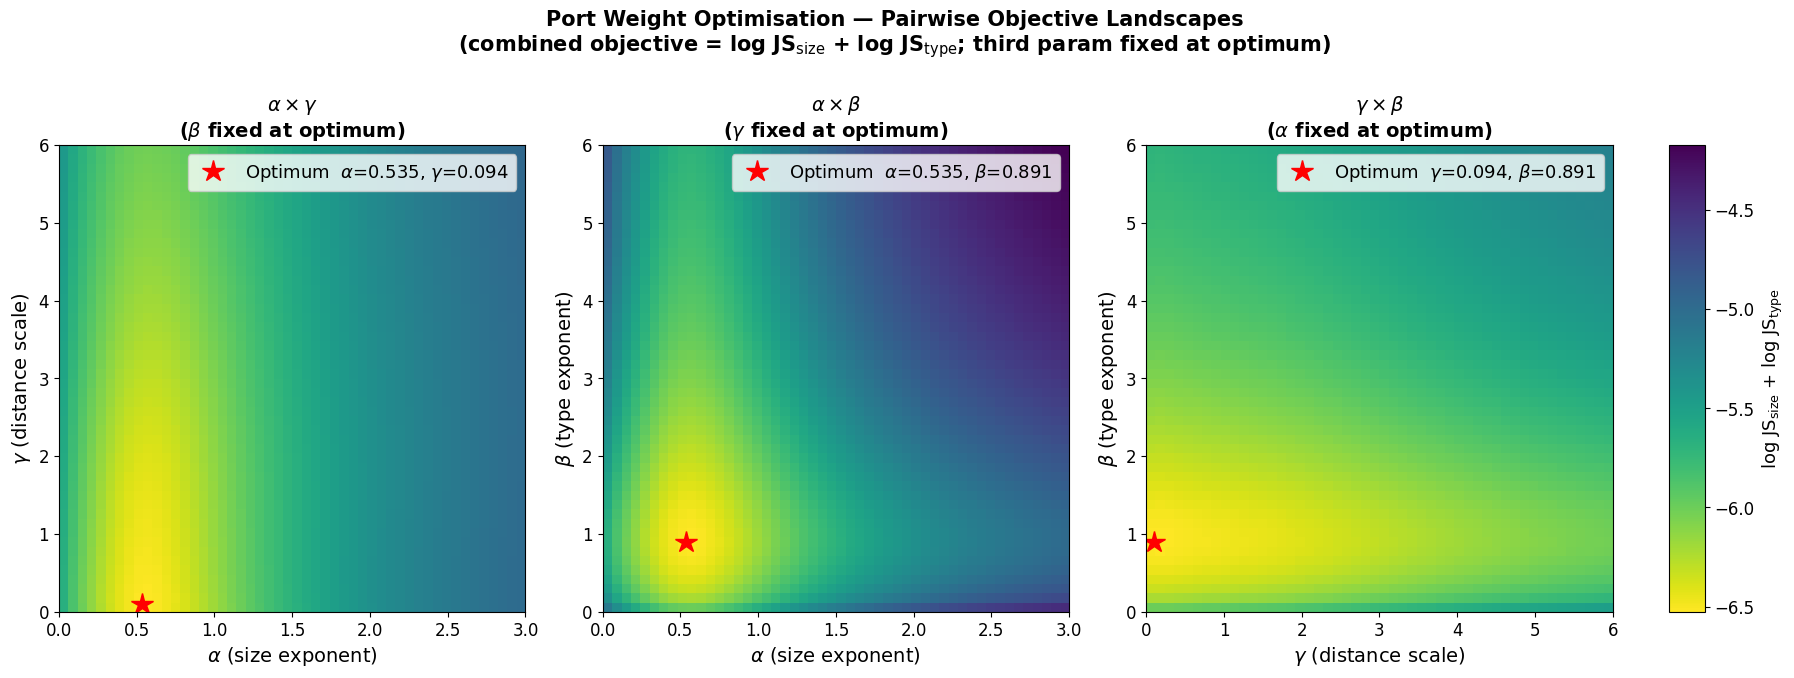

Saved to /Users/finn-frederikhopmann/Documents/Minerva/Academics/Year 4/Semester 7/CP193/Data Fun/simulation_pipeline/part_4_new_simulation/simulation_output_data/scenario_eu_trade_deals_and_tariffs/port_weight_2d_landscapes.png


In [43]:
# ============================================================
# Figure 1 — 1-D landscape slices (3-wide)
# ============================================================
def _slice_plot(ax, xvals, yvals, best_x, best_y, xlabel, ylabel, title, color):
    ax.plot(xvals, yvals, color=color, linewidth=2.5)
    ax.axvline(best_x, color='crimson', linestyle='--', linewidth=2,
               label=f'Optimum = {best_x:.3f}')
    ax.axhline(best_y, color='crimson', linestyle=':', alpha=0.5, linewidth=1.5)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=13)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.3)

fig1, axes1 = plt.subplots(1, 3, figsize=(18, 6))
fig1.suptitle('Port Weight Optimisation — 1-D Objective Slices', fontsize=16, fontweight='bold')

_slice_plot(axes1[0],
            alpha_vals, sweep_js_alpha, opt['best_alpha'], opt['best_js_size'],
            r'$\alpha$ (size exponent)', 'JS_size_vs_vc',
            r'JS_size  vs  $\alpha$' + '\n' + r'($\gamma$ fixed at optimum)', 'steelblue')

_slice_plot(axes1[1],
            lam_vals, sweep_js_lam, opt['best_lam'], opt['best_js_size'],
            r'$\gamma$ (distance scale)', 'JS_size_vs_vc',
            r'JS_size  vs  $\gamma$' + '\n' + r'($\alpha$ fixed at optimum)', 'steelblue')

_slice_plot(axes1[2],
            beta_vals, sweep_js_type, opt['best_beta'], opt['best_js_type'],
            r'$\beta$ (type exponent)', 'JS_type',
            r'JS_type  vs  $\beta$', 'darkorange')

fig1.tight_layout()
fig1.savefig(output_dir / 'port_weight_1d_slices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {output_dir / 'port_weight_1d_slices.png'}")

# ============================================================
# Figure 2 — Pairwise 2-D landscapes (3-wide, shared colorbar)
# Combined objective = log(JS_size) + log(JS_type)
# Third parameter fixed at its optimum in each panel.
# ============================================================
_heatmap_configs = [
    dict(
        grid   = grid_obj_alpha_lam.T,
        extent = [ALPHA_BOUNDS[0], ALPHA_BOUNDS[1], LAM_BOUNDS[0],   LAM_BOUNDS[1]],
        opt_x  = opt['best_alpha'],
        opt_y  = opt['best_lam'],
        xlabel = r'$\alpha$ (size exponent)',
        ylabel = r'$\gamma$ (distance scale)',
        title  = r'$\alpha \times \gamma$' + '\n' + r'($\beta$ fixed at optimum)',
        label  = r'$\alpha$=' + f"{opt['best_alpha']:.3f}" + r', $\gamma$=' + f"{opt['best_lam']:.3f}",
    ),
    dict(
        grid   = grid_obj_alpha_beta.T,
        extent = [ALPHA_BOUNDS[0], ALPHA_BOUNDS[1], BETA_BOUNDS[0],  BETA_BOUNDS[1]],
        opt_x  = opt['best_alpha'],
        opt_y  = opt['best_beta'],
        xlabel = r'$\alpha$ (size exponent)',
        ylabel = r'$\beta$ (type exponent)',
        title  = r'$\alpha \times \beta$' + '\n' + r'($\gamma$ fixed at optimum)',
        label  = r'$\alpha$=' + f"{opt['best_alpha']:.3f}" + r', $\beta$=' + f"{opt['best_beta']:.3f}",
    ),
    dict(
        grid   = grid_obj_lam_beta.T,
        extent = [LAM_BOUNDS[0],   LAM_BOUNDS[1],   BETA_BOUNDS[0],  BETA_BOUNDS[1]],
        opt_x  = opt['best_lam'],
        opt_y  = opt['best_beta'],
        xlabel = r'$\gamma$ (distance scale)',
        ylabel = r'$\beta$ (type exponent)',
        title  = r'$\gamma \times \beta$' + '\n' + r'($\alpha$ fixed at optimum)',
        label  = r'$\gamma$=' + f"{opt['best_lam']:.3f}" + r', $\beta$=' + f"{opt['best_beta']:.3f}",
    ),
]

# Shared color scale across all three panels
_all_grids = [cfg_h['grid'] for cfg_h in _heatmap_configs]
_vmin = min(g.min() for g in _all_grids)
_vmax = max(g.max() for g in _all_grids)

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 7))
fig2.suptitle('Port Weight Optimisation — Pairwise Objective Landscapes\n'
              r'(combined objective = log JS$_\mathrm{size}$ + log JS$_\mathrm{type}$; third param fixed at optimum)',
              fontsize=15, fontweight='bold')

_last_im = None
for ax, cfg_h in zip(axes2, _heatmap_configs):
    im = ax.imshow(
        cfg_h['grid'], origin='lower', aspect='auto',
        extent=cfg_h['extent'], cmap='viridis_r',
        vmin=_vmin, vmax=_vmax,
    )
    ax.set_box_aspect(1)
    ax.plot(cfg_h['opt_x'], cfg_h['opt_y'], 'r*', markersize=16,
            label='Optimum  ' + cfg_h['label'])
    ax.set_xlabel(cfg_h['xlabel'], fontsize=14)
    ax.set_ylabel(cfg_h['ylabel'], fontsize=14)
    ax.set_title(cfg_h['title'], fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=13)
    _last_im = im

# Single shared colorbar sized to match the square panels
fig2.tight_layout(rect=[0, 0, 0.91, 1])
fig2.canvas.draw()
pos = axes2[0].get_position()
cbar_ax = fig2.add_axes([0.93, pos.y0, 0.02, pos.height])
cbar = fig2.colorbar(_last_im, cax=cbar_ax)
cbar.set_label(r'log JS$_\mathrm{size}$ + log JS$_\mathrm{type}$', fontsize=13)
cbar.ax.tick_params(labelsize=12)

fig2.savefig(output_dir / 'port_weight_2d_landscapes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {output_dir / 'port_weight_2d_landscapes.png'}")

In [44]:
# ============================================================
# Per-country breakdown at optimal parameters
# ============================================================
_EPS = 1e-10
best_a = opt['best_alpha']
best_b = opt['best_beta']
best_l = opt['best_lam']

rows = []
for country, pdata in raw_port_data.items():
    n = len(pdata['ports'])
    if n < 2:
        continue

    import_size  = pdata['import_size']
    emp_vc_share = pdata['emp_vc_share']
    emp_type_mx  = pdata['emp_type_mix']
    type_scores  = pdata['type_scores']
    excess       = avg_excess_ratios.get(country, np.zeros(n))

    # JS_size at optimum vs at (alpha=1, lam=0)
    dist_opt = np.exp(-best_l * excess)
    sim_opt  = np.power(np.maximum(import_size, _EPS), best_a) * dist_opt
    sim_opt /= sim_opt.sum()
    sim_ref  = import_size.copy()

    js_size_opt = js_divergence(sim_opt, emp_vc_share)
    js_size_ref = js_divergence(sim_ref, emp_vc_share)

    # JS_type at optimal beta vs beta=0
    sim_type_stack = np.zeros((n, 3))
    for j, st in enumerate(['tanker', 'bulk carrier', 'cargo ship']):
        ts = type_scores[st]
        sim_type_stack[:, j] = np.power(np.maximum(ts, _EPS), best_b) if ts.sum() > 0 else 1.0
    rs = sim_type_stack.sum(axis=1, keepdims=True)
    sim_type_norm = np.where(rs > _EPS, sim_type_stack / rs, 1/3)
    js_type_opt = float(np.average(
        [js_divergence(sim_type_norm[i], emp_type_mx[i]) for i in range(n)],
        weights=import_size,
    ))
    js_type_b0 = float(np.average(
        [js_divergence(np.full(3, 1/3), emp_type_mx[i]) for i in range(n)],
        weights=import_size,
    ))

    rows.append({
        'country':        country,
        'n_ports':        n,
        'js_size_ref':    js_size_ref,
        'js_size_opt':    js_size_opt,
        'size_improve':   js_size_ref - js_size_opt,
        'js_type_b0':     js_type_b0,
        'js_type_opt':    js_type_opt,
        'type_improve':   js_type_b0 - js_type_opt,
    })

df_c = pd.DataFrame(rows)
print(f"Summary across {len(df_c)} countries:\n")
print(f"  JS_size  baseline (α=1, λ=0) : {df_c['js_size_ref'].mean():.4f}")
print(f"  JS_size  at optimum           : {df_c['js_size_opt'].mean():.4f}")
print(f"  JS_type  at β=0               : {df_c['js_type_b0'].mean():.4f}")
print(f"  JS_type  at optimum           : {df_c['js_type_opt'].mean():.4f}")
print()
print("Top 10 by size improvement:")
print(df_c.nlargest(10, 'size_improve')[
    ['country', 'n_ports', 'js_size_ref', 'js_size_opt', 'size_improve']
].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Summary across 108 countries:

  JS_size  baseline (α=1, λ=0) : 0.0361
  JS_size  at optimum           : 0.0252
  JS_type  at β=0               : 0.0984
  JS_type  at optimum           : 0.0581

Top 10 by size improvement:
  country  n_ports  js_size_ref  js_size_opt  size_improve
  Croatia        4       0.2508       0.1417        0.1091
    Qatar        2       0.1995       0.1046        0.0949
  Finland        8       0.1376       0.0492        0.0884
   Canada       11       0.1522       0.0903        0.0619
  Liberia        2       0.0831       0.0246        0.0585
Australia        9       0.1167       0.0604        0.0563
   Guyana        4       0.0669       0.0185        0.0485
   Guinea        2       0.0645       0.0163        0.0482
 Portugal        3       0.0695       0.0218        0.0477
Guatemala        2       0.0663       0.0223        0.0440


In [45]:
# ============================================================
# Final recommendation
# ============================================================
print("=" * 55)
print("RECOMMENDED PARAMETERS")
print("=" * 55)
print(f"  PORT_WEIGHT_ALPHA      = {opt['best_alpha']:.4f}")
print(f"  PORT_WEIGHT_BETA       = {opt['best_beta']:.4f}")
print(f"  DISTANCE_PENALTY_SCALE = {opt['best_lam']:.4f}")
print()
print("Compare to current config:")
cur_a = cfg.get('PORT_WEIGHT_ALPHA', 1.0)
cur_b = cfg.get('PORT_WEIGHT_BETA',  1.0)
cur_l = cfg.get('DISTANCE_PENALTY_SCALE', 3.0)
js_s_cur = compute_js_size_vs_vc(raw_port_data, avg_excess_ratios, cur_a, cur_l)
js_t_cur = compute_js_type(raw_port_data, cur_b)
print(f"  Current  (α={cur_a}, β={cur_b}, λ={cur_l}):")
print(f"    JS_size={js_s_cur:.5f}  JS_type={js_t_cur:.5f}")
print(f"  Optimal  (α={opt['best_alpha']:.4f}, β={opt['best_beta']:.4f}, λ={opt['best_lam']:.4f}):")
print(f"    JS_size={opt['best_js_size']:.5f}  JS_type={opt['best_js_type']:.5f}")
print()
print("Next step: copy the three values above into simulation_config.json,")
print("           then re-run 01_ship_generation.ipynb.")

RECOMMENDED PARAMETERS
  PORT_WEIGHT_ALPHA      = 0.5349
  PORT_WEIGHT_BETA       = 0.8908
  DISTANCE_PENALTY_SCALE = 0.0942

Compare to current config:
  Current  (α=0.5349, β=0.8908, λ=0.0942):
    JS_size=0.02522  JS_type=0.05805
  Optimal  (α=0.5349, β=0.8908, λ=0.0942):
    JS_size=0.02522  JS_type=0.05805

Next step: copy the three values above into simulation_config.json,
           then re-run 01_ship_generation.ipynb.
